# LDA — Serial vs OpenMP vs CUDA Comparison
### HPC Mini Project — Topic 42 · Bonus (GPU)

This notebook extends `lda_hpc.ipynb` with a **CUDA GPU implementation** of the  
within-class scatter matrix S_W, then benchmarks and compares all three backends:

| Backend | Source | Parallelism |
|---------|--------|-------------|
| Serial  | `serial/lda_serial.so`  | 1 CPU thread |
| OpenMP  | `parallel/lda_openmp.so` | N CPU threads |
| CUDA    | `bonus/lda_cuda.so`      | thousands of GPU threads |


## 0 · Imports & Setup

In [1]:
import ctypes, os, subprocess, time, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.patches as mpatches
from scipy.linalg import eigh
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder, StandardScaler

np.random.seed(42)
print('imports OK')


imports OK


## 1 · Compile All Libraries

In [2]:
SERIAL_DIR   = 'serial'
PARALLEL_DIR = 'parallel'
CUDA_DIR     = 'bonus'

def compile_lib(directory, target, extra_info=''):
    result = subprocess.run(['make', '-C', directory, '-B'],
                            capture_output=True, text=True)
    if result.returncode != 0:
        print(result.stderr)
        raise RuntimeError(f'Compilation failed in {directory}')
    path = os.path.join(directory, target)
    assert os.path.exists(path), f'{path} not found after make'
    print(f'  ✓  {path}  {extra_info}')
    return os.path.abspath(path)

print('Compiling...')
serial_so   = compile_lib(SERIAL_DIR,   'lda_serial.so')
parallel_so = compile_lib(PARALLEL_DIR, 'lda_openmp.so')
cuda_so     = compile_lib(CUDA_DIR,     'lda_cuda.so', '(GPU)')


Compiling...
  ✓  serial/lda_serial.so  
  ✓  parallel/lda_openmp.so  
  ✓  bonus/lda_cuda.so  (GPU)


## 2 · ctypes Bindings

In [3]:
c_double_p = ctypes.POINTER(ctypes.c_double)
c_int_p    = ctypes.POINTER(ctypes.c_int)

def _bind(lib, name, argtypes, restype=None):
    fn = getattr(lib, name)
    fn.argtypes = argtypes
    fn.restype  = restype if restype else ctypes.c_double
    return fn

# ── serial ────────────────────────────────────────────────────────────────
_serial = ctypes.CDLL(serial_so)

_serial_means = _bind(_serial, 'compute_class_means',
    [c_double_p, c_int_p, ctypes.c_int, ctypes.c_int, ctypes.c_int,
     c_double_p, c_int_p, c_double_p], restype=None)

_serial_sw = _bind(_serial, 'compute_sw',
    [c_double_p, c_int_p, c_double_p,
     ctypes.c_int, ctypes.c_int, ctypes.c_int, c_double_p])

_serial_sb = _bind(_serial, 'compute_sb',
    [c_double_p, c_double_p, c_int_p,
     ctypes.c_int, ctypes.c_int, c_double_p], restype=None)

_serial_proj = _bind(_serial, 'lda_project',
    [c_double_p, c_double_p, ctypes.c_int, ctypes.c_int, ctypes.c_int,
     c_double_p], restype=None)

# ── parallel (OpenMP) ─────────────────────────────────────────────────────
_par = ctypes.CDLL(parallel_so)

_par_means = _bind(_par, 'compute_class_means',
    [c_double_p, c_int_p, ctypes.c_int, ctypes.c_int, ctypes.c_int,
     c_double_p, c_int_p, c_double_p], restype=None)

_par_sw = _bind(_par, 'compute_sw_parallel',
    [c_double_p, c_int_p, c_double_p,
     ctypes.c_int, ctypes.c_int, ctypes.c_int,
     c_double_p, ctypes.c_int])

_par_sb = _bind(_par, 'compute_sb',
    [c_double_p, c_double_p, c_int_p,
     ctypes.c_int, ctypes.c_int, c_double_p], restype=None)

_par_proj = _bind(_par, 'lda_project',
    [c_double_p, c_double_p, ctypes.c_int, ctypes.c_int, ctypes.c_int,
     c_double_p], restype=None)

# ── CUDA ──────────────────────────────────────────────────────────────────
_cuda = ctypes.CDLL(cuda_so)

_cuda_means = _bind(_cuda, 'compute_class_means',
    [c_double_p, c_int_p, ctypes.c_int, ctypes.c_int, ctypes.c_int,
     c_double_p, c_int_p, c_double_p], restype=None)

_cuda_sw = _bind(_cuda, 'compute_sw_cuda',
    [c_double_p, c_int_p, c_double_p,
     ctypes.c_int, ctypes.c_int, ctypes.c_int, c_double_p])

_cuda_sb = _bind(_cuda, 'compute_sb',
    [c_double_p, c_double_p, c_int_p,
     ctypes.c_int, ctypes.c_int, c_double_p], restype=None)

_cuda_proj = _bind(_cuda, 'lda_project_cuda',
    [c_double_p, c_double_p, ctypes.c_int, ctypes.c_int, ctypes.c_int,
     c_double_p], restype=None)

# GPU name query
_get_gpu = _cuda.get_gpu_name
_get_gpu.argtypes = [ctypes.c_char_p, ctypes.c_int]
_get_gpu.restype  = None
buf = ctypes.create_string_buffer(256)
_get_gpu(buf, 256)
GPU_NAME = buf.value.decode()

print('ctypes bindings OK')
print(f'GPU: {GPU_NAME}')


ctypes bindings OK
GPU: NVIDIA GeForce GTX 1650 Ti


## 3 · Load & Prepare Dataset

In [5]:
DATA_DIR = 'data'
train_df = pd.read_csv(f'{DATA_DIR}/train.csv')
test_df  = pd.read_csv(f'{DATA_DIR}/test.csv')
print(f'Train: {train_df.shape}  Test: {test_df.shape}')

le = LabelEncoder()
X_train = train_df.drop(columns=['subject','Activity']).values.astype(np.float64)
y_train = le.fit_transform(train_df['Activity'].values).astype(np.int32)
X_test  = test_df.drop(columns=['subject','Activity']).values.astype(np.float64)
y_test  = le.transform(test_df['Activity'].values).astype(np.int32)

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train).astype(np.float64)
X_test  = scaler.transform(X_test).astype(np.float64)

n, d = X_train.shape
C    = len(le.classes_)
K    = C - 1

print(f'n={n}, d={d}, C={C}, K={K}')
print('Classes:', le.classes_)
print('Features scaled with StandardScaler — ready')


Train: (7352, 563)  Test: (2947, 563)
n=7352, d=561, C=6, K=5
Classes: ['LAYING' 'SITTING' 'STANDING' 'WALKING' 'WALKING_DOWNSTAIRS'
 'WALKING_UPSTAIRS']
Features scaled with StandardScaler — ready


## 4 · ctypes Pointer Helpers

In [6]:
def dptr(arr):
    arr = np.ascontiguousarray(arr, dtype=np.float64)
    return arr.ctypes.data_as(c_double_p)

def iptr(arr):
    arr = np.ascontiguousarray(arr, dtype=np.int32)
    return arr.ctypes.data_as(c_int_p)


## 5 · LDA Pipeline Functions

In [7]:
def run_serial_lda(X, y, n, d, C):
    means       = np.zeros((C, d), dtype=np.float64)
    counts      = np.zeros(C,      dtype=np.int32)
    global_mean = np.zeros(d,      dtype=np.float64)
    SW          = np.zeros((d, d), dtype=np.float64)
    SB          = np.zeros((d, d), dtype=np.float64)

    _serial_means(dptr(X), iptr(y), n, d, C,
                  dptr(means), iptr(counts), dptr(global_mean))
    t_sw = _serial_sw(dptr(X), iptr(y), dptr(means), n, d, C, dptr(SW))
    _serial_sb(dptr(means), dptr(global_mean), iptr(counts), d, C, dptr(SB))

    eigenvalues, eigenvectors = eigh(SB, SW + 1e-6 * np.eye(d))
    W = eigenvectors[:, -K:][:, ::-1].copy(order='C')
    return W, SW, SB, t_sw, means, global_mean, counts


def run_openmp_lda(X, y, n, d, C, num_threads):
    means       = np.zeros((C, d), dtype=np.float64)
    counts      = np.zeros(C,      dtype=np.int32)
    global_mean = np.zeros(d,      dtype=np.float64)
    SW          = np.zeros((d, d), dtype=np.float64)
    SB          = np.zeros((d, d), dtype=np.float64)

    _par_means(dptr(X), iptr(y), n, d, C,
               dptr(means), iptr(counts), dptr(global_mean))
    t_sw = _par_sw(dptr(X), iptr(y), dptr(means), n, d, C, dptr(SW), num_threads)
    _par_sb(dptr(means), dptr(global_mean), iptr(counts), d, C, dptr(SB))

    eigenvalues, eigenvectors = eigh(SB, SW + 1e-6 * np.eye(d))
    W = eigenvectors[:, -K:][:, ::-1].copy(order='C')
    return W, SW, SB, t_sw


def run_cuda_lda(X, y, n, d, C):
    means       = np.zeros((C, d), dtype=np.float64)
    counts      = np.zeros(C,      dtype=np.int32)
    global_mean = np.zeros(d,      dtype=np.float64)
    SW          = np.zeros((d, d), dtype=np.float64)
    SB          = np.zeros((d, d), dtype=np.float64)

    _cuda_means(dptr(X), iptr(y), n, d, C,
                dptr(means), iptr(counts), dptr(global_mean))
    t_sw = _cuda_sw(dptr(X), iptr(y), dptr(means), n, d, C, dptr(SW))
    _cuda_sb(dptr(means), dptr(global_mean), iptr(counts), d, C, dptr(SB))

    eigenvalues, eigenvectors = eigh(SB, SW + 1e-6 * np.eye(d))
    W = eigenvectors[:, -K:][:, ::-1].copy(order='C')
    return W, SW, SB, t_sw


print('Pipeline functions defined')


Pipeline functions defined


## 6 · Run All Three Backends

In [9]:
OMP_THREADS = 8  

print('─' * 55)
print('Running serial LDA...')
W_serial, SW_s, SB_s, t_serial, means_s, gm_s, cnt_s = \
    run_serial_lda(X_train, y_train, n, d, C)
print(f'  S_W time  : {t_serial:.4f} s')

print('Running OpenMP LDA...')
W_omp, SW_o, _, t_omp = run_openmp_lda(X_train, y_train, n, d, C, OMP_THREADS)
print(f'  S_W time  : {t_omp:.4f} s  ({t_serial/t_omp:.2f}x vs serial)')

print('Running CUDA LDA...')
W_cuda, SW_c, _, t_cuda = run_cuda_lda(X_train, y_train, n, d, C)
print(f'  S_W time  : {t_cuda:.4f} s  ({t_serial/t_cuda:.2f}x vs serial)')
print('─' * 55)


───────────────────────────────────────────────────────
Running serial LDA...
  S_W time  : 1.2789 s
Running OpenMP LDA...
  S_W time  : 0.9657 s  (1.32x vs serial)
Running CUDA LDA...
  S_W time  : 1.8847 s  (0.68x vs serial)
───────────────────────────────────────────────────────


## 7 · Correctness Check

In [10]:
def check_match(ref, other, name):
    diff = np.max(np.abs(ref - other))
    rel  = diff / (np.max(np.abs(ref)) + 1e-15)
    status = '✓' if rel < 1e-8 else '✗'
    print(f'{status}  Serial vs {name:8s}  max_abs={diff:.2e}  rel={rel:.2e}')
    return rel < 1e-8

ok1 = check_match(SW_s, SW_o, 'OpenMP')
ok2 = check_match(SW_s, SW_c, 'CUDA')

assert ok1, 'OpenMP S_W diverges from serial!'
assert ok2, 'CUDA S_W diverges from serial!'
print('\nAll backends agree to machine precision ✓')


✓  Serial vs OpenMP    max_abs=4.70e-10  rel=6.40e-14
✓  Serial vs CUDA      max_abs=4.47e-10  rel=6.08e-14

All backends agree to machine precision ✓


## 8 · Full Benchmark

In [11]:
N_REPEATS   = 5
OMP_CONFIGS = [1, 2, 4, 6, 8]   # thread counts to sweep

results = []

# ── serial baseline ───────────────────────────────────────────────────────
times = []
for _ in range(N_REPEATS):
    SW_tmp = np.zeros((d,d), dtype=np.float64)
    m_tmp  = np.zeros((C,d), dtype=np.float64)
    c_tmp  = np.zeros(C,     dtype=np.int32)
    g_tmp  = np.zeros(d,     dtype=np.float64)
    _serial_means(dptr(X_train), iptr(y_train), n, d, C,
                  dptr(m_tmp), iptr(c_tmp), dptr(g_tmp))
    times.append(_serial_sw(dptr(X_train), iptr(y_train), dptr(m_tmp),
                             n, d, C, dptr(SW_tmp)))

t_serial_ref = np.mean(times)
results.append({'backend':'serial','threads':1,
                'time_mean':t_serial_ref,'time_std':np.std(times),
                'speedup':1.0})
print(f'Serial   : {t_serial_ref:.4f} s  (baseline)')

# ── OpenMP sweep ──────────────────────────────────────────────────────────
for T in OMP_CONFIGS:
    times = []
    for _ in range(N_REPEATS):
        SW_tmp = np.zeros((d,d), dtype=np.float64)
        m_tmp  = np.zeros((C,d), dtype=np.float64)
        c_tmp  = np.zeros(C,     dtype=np.int32)
        g_tmp  = np.zeros(d,     dtype=np.float64)
        _par_means(dptr(X_train), iptr(y_train), n, d, C,
                   dptr(m_tmp), iptr(c_tmp), dptr(g_tmp))
        times.append(_par_sw(dptr(X_train), iptr(y_train), dptr(m_tmp),
                              n, d, C, dptr(SW_tmp), T))
    mean_t  = np.mean(times)
    speedup = t_serial_ref / mean_t
    results.append({'backend':f'OpenMP-{T}T','threads':T,
                    'time_mean':mean_t,'time_std':np.std(times),
                    'speedup':speedup})
    print(f'OpenMP {T:2d}T: {mean_t:.4f} s  speedup={speedup:.2f}x')

# ── CUDA ──────────────────────────────────────────────────────────────────
times = []
for _ in range(N_REPEATS):
    SW_tmp = np.zeros((d,d), dtype=np.float64)
    m_tmp  = np.zeros((C,d), dtype=np.float64)
    c_tmp  = np.zeros(C,     dtype=np.int32)
    g_tmp  = np.zeros(d,     dtype=np.float64)
    _cuda_means(dptr(X_train), iptr(y_train), n, d, C,
                dptr(m_tmp), iptr(c_tmp), dptr(g_tmp))
    times.append(_cuda_sw(dptr(X_train), iptr(y_train), dptr(m_tmp),
                           n, d, C, dptr(SW_tmp)))

mean_cuda  = np.mean(times)
speedup_cuda = t_serial_ref / mean_cuda
results.append({'backend':f'CUDA ({GPU_NAME})','threads':None,
                'time_mean':mean_cuda,'time_std':np.std(times),
                'speedup':speedup_cuda})
print(f'CUDA     : {mean_cuda:.4f} s  speedup={speedup_cuda:.2f}x  [{GPU_NAME}]')

results_df = pd.DataFrame(results)
print()
print(results_df[['backend','time_mean','time_std','speedup']].to_string(index=False))


Serial   : 1.1894 s  (baseline)
OpenMP  1T: 0.5134 s  speedup=2.32x
OpenMP  2T: 0.4516 s  speedup=2.63x
OpenMP  4T: 0.6726 s  speedup=1.77x
OpenMP  6T: 0.9439 s  speedup=1.26x
OpenMP  8T: 1.0459 s  speedup=1.14x
CUDA     : 1.7539 s  speedup=0.68x  [NVIDIA GeForce GTX 1650 Ti]

                          backend  time_mean  time_std  speedup
                           serial   1.189440  0.086923 1.000000
                        OpenMP-1T   0.513387  0.010498 2.316848
                        OpenMP-2T   0.451577  0.033715 2.633971
                        OpenMP-4T   0.672645  0.030960 1.768303
                        OpenMP-6T   0.943861  0.041357 1.260185
                        OpenMP-8T   1.045864  0.090768 1.137279
CUDA (NVIDIA GeForce GTX 1650 Ti)   1.753883  0.101652 0.678175


## 9 · Visualisations

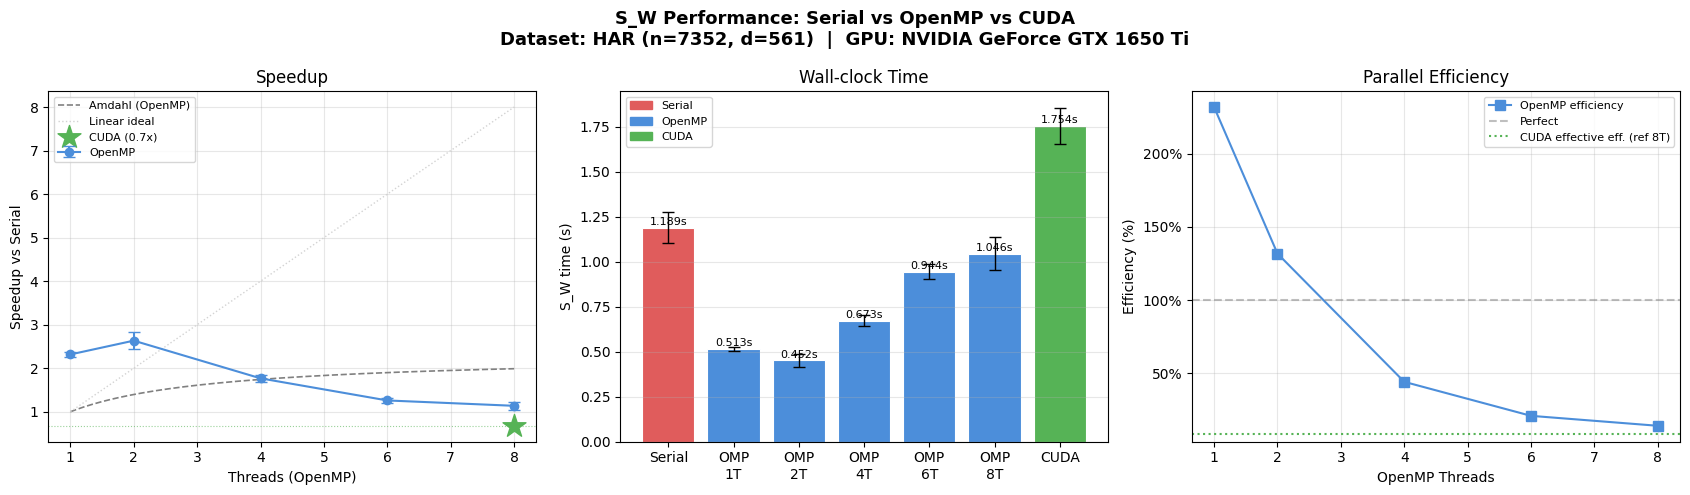

Saved figures/comparison_speedup.png


In [12]:
os.makedirs('figures', exist_ok=True)

COLORS = {
    'serial' : '#e05c5c',
    'openmp' : '#4c8eda',
    'cuda'   : '#56b356',
}

omp_df  = results_df[results_df['backend'].str.startswith('OpenMP')].copy()
omp_df['threads'] = omp_df['threads'].astype(int)
cuda_row = results_df[results_df['backend'].str.startswith('CUDA')].iloc[0]

# ── Amdahl for OpenMP ─────────────────────────────────────────────────────
t1_omp = omp_df[omp_df['threads']==1]['time_mean'].values[0]
p_omp  = 1 - (t1_omp / t_serial_ref)
T_range = np.linspace(1, omp_df['threads'].max(), 200)
amdahl  = 1.0 / ((1-p_omp) + p_omp / T_range)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle(
    f'S_W Performance: Serial vs OpenMP vs CUDA\n'
    f'Dataset: HAR (n={n}, d={d})  |  GPU: {GPU_NAME}',
    fontsize=13, fontweight='bold'
)

# ── Plot 1: Speedup ───────────────────────────────────────────────────────
ax = axes[0]
ax.plot(T_range, amdahl, '--', color='gray', lw=1.2, label='Amdahl (OpenMP)')
ax.plot(T_range, T_range, ':',  color='lightgray', lw=1, label='Linear ideal')
ax.errorbar(omp_df['threads'], omp_df['speedup'],
            yerr=omp_df['time_std']/omp_df['time_mean']*omp_df['speedup'],
            fmt='o-', color=COLORS['openmp'], capsize=4, label='OpenMP', zorder=5)

# CUDA as a star on the right edge
ax.scatter([omp_df['threads'].max()], [cuda_row['speedup']],
           marker='*', s=300, color=COLORS['cuda'], zorder=6,
           label=f"CUDA ({cuda_row['speedup']:.1f}x)")
ax.axhline(cuda_row['speedup'], color=COLORS['cuda'], lw=0.8, ls=':', alpha=0.6)

ax.set_xlabel('Threads (OpenMP)'); ax.set_ylabel('Speedup vs Serial')
ax.set_title('Speedup')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# ── Plot 2: Wall-clock time bar chart ─────────────────────────────────────
ax = axes[1]
labels_bar  = ['Serial'] + [f'OMP\n{T}T' for T in omp_df['threads']] + ['CUDA']
times_bar   = ([t_serial_ref]
               + list(omp_df['time_mean'])
               + [cuda_row['time_mean']])
errors_bar  = ([results_df[results_df['backend']=='serial']['time_std'].values[0]]
               + list(omp_df['time_std'])
               + [cuda_row['time_std']])
bar_colors  = ([COLORS['serial']]
               + [COLORS['openmp']] * len(omp_df)
               + [COLORS['cuda']])

bars = ax.bar(labels_bar, times_bar, color=bar_colors,
              edgecolor='white', linewidth=0.8)
ax.errorbar(range(len(labels_bar)), times_bar, yerr=errors_bar,
            fmt='none', color='black', capsize=4, linewidth=1)

for bar, t in zip(bars, times_bar):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{t:.3f}s', ha='center', va='bottom', fontsize=8)

ax.set_ylabel('S_W time (s)'); ax.set_title('Wall-clock Time')
ax.grid(axis='y', alpha=0.3)

patches = [
    mpatches.Patch(color=COLORS['serial'], label='Serial'),
    mpatches.Patch(color=COLORS['openmp'], label='OpenMP'),
    mpatches.Patch(color=COLORS['cuda'],   label='CUDA'),
]
ax.legend(handles=patches, fontsize=8)

# ── Plot 3: OpenMP efficiency + CUDA reference line ───────────────────────
ax = axes[2]
omp_df_c = omp_df.copy()
omp_df_c['efficiency'] = omp_df_c['speedup'] / omp_df_c['threads'] * 100

ax.plot(omp_df_c['threads'], omp_df_c['efficiency'],
        's-', color=COLORS['openmp'], markersize=7, label='OpenMP efficiency')
ax.axhline(100, linestyle='--', color='gray', alpha=0.5, label='Perfect')
ax.axhline(cuda_row['speedup'] / omp_df_c['threads'].max() * 100,
           linestyle=':', color=COLORS['cuda'], lw=1.5,
           label=f'CUDA effective eff. (ref {omp_df_c["threads"].max()}T)')

ax.set_xlabel('OpenMP Threads'); ax.set_ylabel('Efficiency (%)')
ax.set_title('Parallel Efficiency')
ax.yaxis.set_major_formatter(ticker.PercentFormatter())
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/comparison_speedup.png', dpi=150)
plt.show()
print('Saved figures/comparison_speedup.png')


## 10 · LDA Projection (all 3 backends)

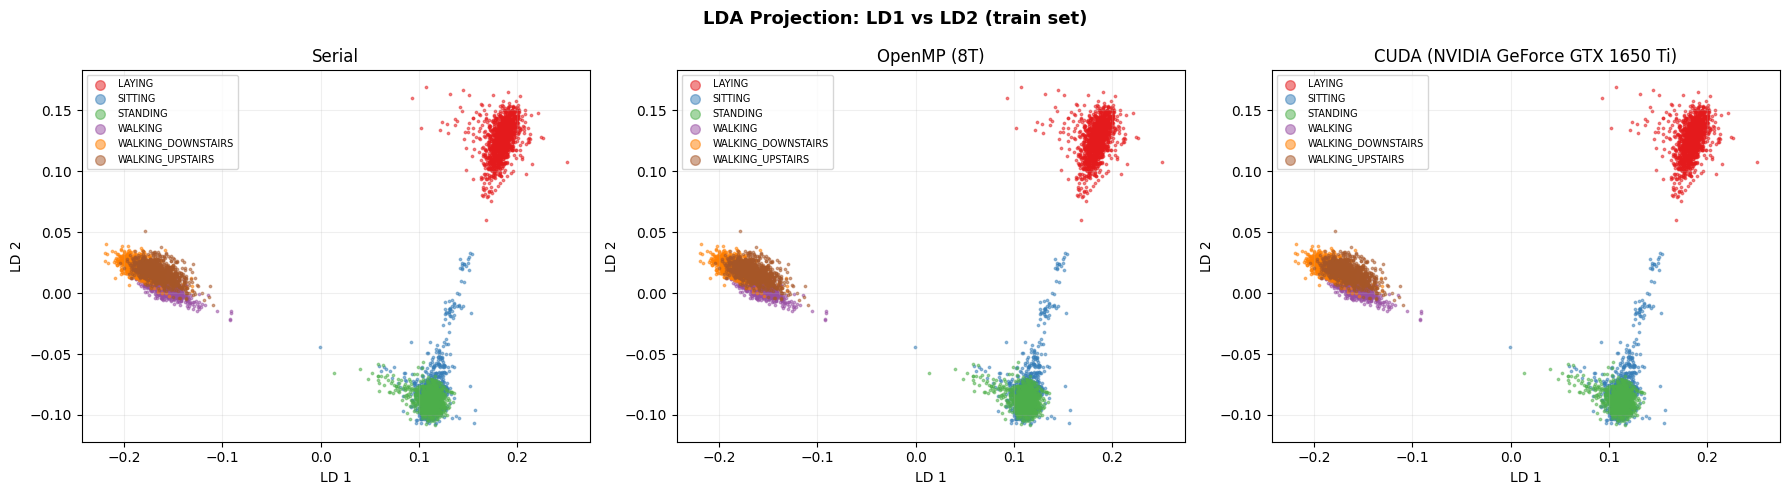

Saved figures/comparison_projection.png


In [13]:
PROJ_COLORS = ['#e41a1c','#377eb8','#4daf4a','#984ea3','#ff7f00','#a65628']

X_train_c = np.ascontiguousarray(X_train, dtype=np.float64)
X_test_c  = np.ascontiguousarray(X_test,  dtype=np.float64)

def project_all(W_mat, proj_fn):
    W_c = np.ascontiguousarray(W_mat, dtype=np.float64)
    Ytr = np.zeros((n, K),           dtype=np.float64)
    Yte = np.zeros((len(y_test), K), dtype=np.float64)
    proj_fn(dptr(X_train_c), dptr(W_c), n, d, K, dptr(Ytr))
    proj_fn(dptr(X_test_c),  dptr(W_c), len(y_test), d, K, dptr(Yte))
    return Ytr, Yte

Ytr_s, Yte_s = project_all(W_serial, _serial_proj)
Ytr_o, Yte_o = project_all(W_omp,    _par_proj)
Ytr_c, Yte_c = project_all(W_cuda,   _cuda_proj)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('LDA Projection: LD1 vs LD2 (train set)', fontsize=13, fontweight='bold')

for ax, Ytr, title in zip(axes,
                           [Ytr_s, Ytr_o, Ytr_c],
                           ['Serial', f'OpenMP ({OMP_THREADS}T)', f'CUDA ({GPU_NAME})']):
    for c_idx, lbl in enumerate(le.classes_):
        mask = y_train == c_idx
        ax.scatter(Ytr[mask,0], Ytr[mask,1],
                   s=3, alpha=0.5, color=PROJ_COLORS[c_idx], label=lbl)
    ax.set_title(title); ax.set_xlabel('LD 1'); ax.set_ylabel('LD 2')
    ax.legend(markerscale=4, fontsize=7); ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('figures/comparison_projection.png', dpi=150)
plt.show()
print('Saved figures/comparison_projection.png')


## 11 · Classification Accuracy (1-NN on LDA space)

In [14]:
def knn_accuracy(Ytr, Yte, y_tr, y_te):
    knn = KNeighborsClassifier(n_neighbors=1)
    knn.fit(Ytr, y_tr)
    return accuracy_score(y_te, knn.predict(Yte))

acc_s    = knn_accuracy(Ytr_s, Yte_s, y_train, y_test)
acc_omp  = knn_accuracy(Ytr_o, Yte_o, y_train, y_test)
acc_cuda = knn_accuracy(Ytr_c, Yte_c, y_train, y_test)

print(f'Serial   accuracy: {acc_s:.4f}  ({acc_s*100:.2f}%)')
print(f'OpenMP   accuracy: {acc_omp:.4f}  ({acc_omp*100:.2f}%)')
print(f'CUDA     accuracy: {acc_cuda:.4f}  ({acc_cuda*100:.2f}%)')
print()
print('Note: small numerical differences are expected due to floating-point')
print('ordering, but all should agree to ≥ 4 decimal places.')


Serial   accuracy: 0.9644  (96.44%)
OpenMP   accuracy: 0.9644  (96.44%)
CUDA     accuracy: 0.9644  (96.44%)

Note: small numerical differences are expected due to floating-point
ordering, but all should agree to ≥ 4 decimal places.


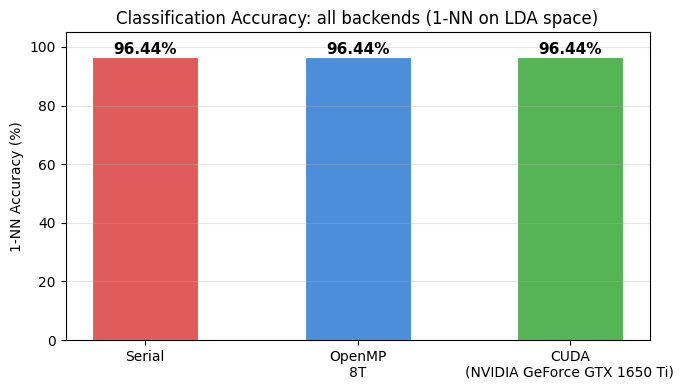

Saved figures/comparison_accuracy.png


In [15]:
fig, ax = plt.subplots(figsize=(7, 4))
backends = ['Serial', f'OpenMP\n{OMP_THREADS}T', f'CUDA\n({GPU_NAME})']
accs     = [acc_s, acc_omp, acc_cuda]
colors   = [COLORS['serial'], COLORS['openmp'], COLORS['cuda']]

bars = ax.bar(backends, [a*100 for a in accs], color=colors,
              edgecolor='white', linewidth=0.8, width=0.5)
for bar, a in zip(bars, accs):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
            f'{a*100:.2f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylabel('1-NN Accuracy (%)')
ax.set_title('Classification Accuracy: all backends (1-NN on LDA space)')
ax.set_ylim(0, 105)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('figures/comparison_accuracy.png', dpi=150)
plt.show()
print('Saved figures/comparison_accuracy.png')


## 12 · Summary Table

In [16]:
import os
print('=== S_W Timing & Speedup Summary ===')
summary = results_df[['backend','time_mean','time_std','speedup']].copy()
summary['time_mean'] = summary['time_mean'].map('{:.4f} s'.format)
summary['time_std']  = summary['time_std'].map('{:.4f} s'.format)
summary['speedup']   = summary['speedup'].map('{:.2f}x'.format)
print(summary.to_string(index=False))

print()
print('=== Classification Accuracy ===')
print(f'  Serial  : {acc_s:.4f}')
print(f'  OpenMP  : {acc_omp:.4f}')
print(f'  CUDA    : {acc_cuda:.4f}')

print()
print(f'=== Environment ===')
print(f'  GPU     : {GPU_NAME}')
print(f'  CPUs    : {os.cpu_count()}')
import subprocess
omp_info = subprocess.run(['lscpu'], capture_output=True, text=True)
for line in omp_info.stdout.split('\n'):
    if any(k in line for k in ['Model name','CPU(s)','Thread']):
        print(f'  {line.strip()}')


=== S_W Timing & Speedup Summary ===
                          backend time_mean time_std speedup
                           serial  1.1894 s 0.0869 s   1.00x
                        OpenMP-1T  0.5134 s 0.0105 s   2.32x
                        OpenMP-2T  0.4516 s 0.0337 s   2.63x
                        OpenMP-4T  0.6726 s 0.0310 s   1.77x
                        OpenMP-6T  0.9439 s 0.0414 s   1.26x
                        OpenMP-8T  1.0459 s 0.0908 s   1.14x
CUDA (NVIDIA GeForce GTX 1650 Ti)  1.7539 s 0.1017 s   0.68x

=== Classification Accuracy ===
  Serial  : 0.9644
  OpenMP  : 0.9644
  CUDA    : 0.9644

=== Environment ===
  GPU     : NVIDIA GeForce GTX 1650 Ti
  CPUs    : 8
  CPU(s):                               8
  On-line CPU(s) list:                  0-7
  Model name:                           Intel(R) Core(TM) i5-10300H CPU @ 2.50GHz
  Thread(s) per core:                   2
  NUMA node0 CPU(s):                    0-7
